# AI Job Replacement Data Analysis

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data cleaning

In [29]:
df = pd.read_csv('../data/ai_job_replacement_2020_2026_v2.csv')

In [3]:
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [4]:
df = df.drop(columns=['job_id'])

In [5]:
print('Any duplicates: ', df.duplicated().any())

Any duplicates:  False


In [6]:
df.head()

,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [7]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64


In [8]:
# No need to check outliers

In [9]:
df.dtypes

job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level              float64
education_requirement_level      int64
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object

In [10]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 15000 rows, 19 columns


In [11]:
# Key columns explanation:

# automation_risk_percent is the estimated probability that the job could be replaced by AI.
# The higher, the higher the risk

# ai_replacement_score is a normalized score, estimating how likely AI could replace this role.
# This could include factors such as task automation, AI adoption, and skillset

# skill_gap_index measures the difference between current worker skills and the skills required in an AI-driven environment.
# Higher value indicate a significant skill mismatch

# skill_demand_growth_percent refers to the demand for skills associated with this job.
# Higher percent indicates big growth

# skill_transition_pressure indicates how strongly workers in this job must shift to new skills due to AI changes
# Higher value means more pressure to transition

# reskilling_urgency_score is about how urgently workers need to learn new skills to stay employable.
# Higher value means it's more urgent

# remote_feasibility_score measures how easily the job can be performed remotely
# Higher value means it's more feasible

# ai_adoption_level is the degree to which AI is adopted in that job, a maturity index level taking into account industry and country
# Higher value means more mature

# ai_disruption_intensity measures how strongly AI is disrupting the role, considering automation risk, skills changes, wage impact, and AI adoption
# Higher value means more disruption

# education_requirement_level encodes the level of education required for the role.
# 1 means high school, 5 means PhD

# wage_volatility_index indicates how unstable wages are for that role due to technological changes.
# Higher value means salaries fluctuate more and job market uncertainty is higher

In [12]:
print(df.describe())

               year  automation_risk_percent  ai_replacement_score  \
count  15000.000000             15000.000000          15000.000000   
mean    2022.997200                46.176347             46.155907   
std        1.999365                21.663635             22.351347   
min     2020.000000                 5.000000              4.010000   
25%     2021.000000                28.790000             28.357500   
50%     2023.000000                46.235000             45.675000   
75%     2025.000000                63.602500             62.712500   
max     2026.000000                94.980000            113.070000   

       skill_gap_index  salary_before_usd  salary_after_usd  \
count     15000.000000       15000.000000      15000.000000   
mean         50.003708       89771.375196      89870.633937   
std          28.811040       34522.125434      35897.592992   
min           0.000000       30003.690000      19022.670000   
25%          25.170000       60127.225000      59223.4

In [28]:
df['job_role'].unique()

array(['Data Analyst', 'Accountant', 'Teacher', 'Customer Support Rep',
       'Software Engineer', 'Marketing Specialist', 'Financial Analyst',
       'HR Manager', 'Mechanical Engineer', 'Truck Driver'], dtype=object)

In [56]:
sorted(df['year'].unique())

[2020, 2021, 2022, 2023, 2024, 2025, 2026]

In [13]:
values = {
    1: 'High school',
    2: 'Diploma',
    3: 'Bachelor\'s',
    4: 'Master\'s',
    5: 'PhD'
}

df['education_requirement_level'] = df['education_requirement_level'].map(values)

## Data exploration

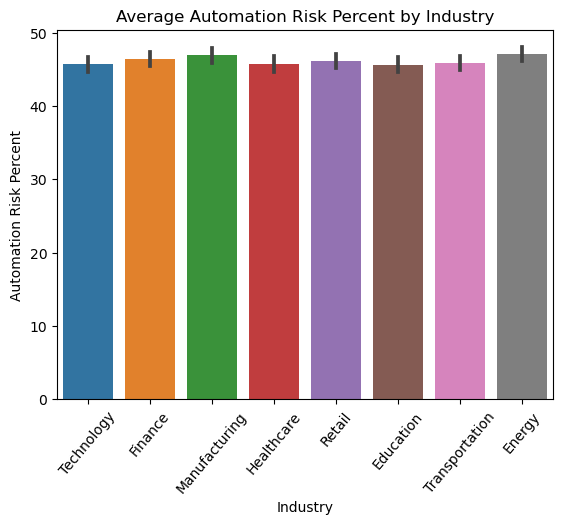

In [14]:
sns.barplot(x='industry', y='automation_risk_percent', data=df)

plt.title('Average Automation Risk Percent by Industry')
plt.xlabel('Industry')
plt.ylabel('Automation Risk Percent')
plt.xticks(rotation=50)
plt.show()

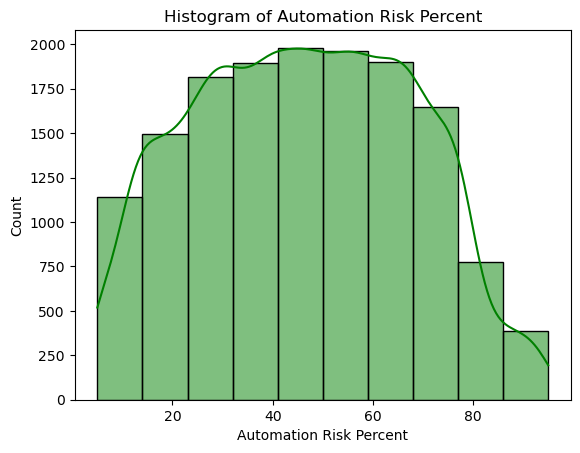

In [15]:
sns.histplot(x='automation_risk_percent', data=df, kde=True, color='green', bins=10)
plt.title('Histogram of Automation Risk Percent')
plt.xlabel('Automation Risk Percent')
plt.show()

<Axes: xlabel='ai_adoption_level', ylabel='automation_risk_percent'>

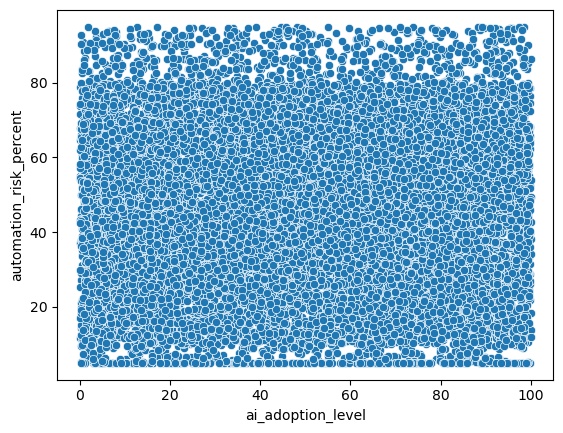

In [16]:
sns.scatterplot(x='ai_adoption_level', y='automation_risk_percent', data=df)

In [17]:
# Each industries are evenly matched with the average automation risk percent
# The scatterplot does not show any clear correlation with AI adoption level

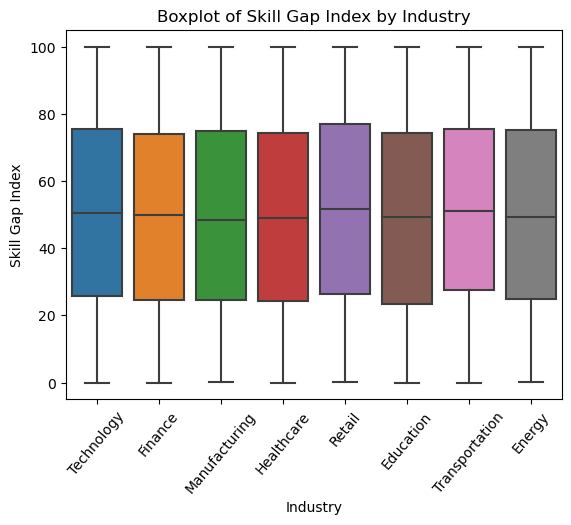

In [18]:
sns.boxplot(x='industry', y='skill_gap_index', data=df)
plt.title('Boxplot of Skill Gap Index by Industry')
plt.xlabel('Industry')
plt.ylabel('Skill Gap Index')
plt.xticks(rotation=50)
plt.show()

In [38]:
df.groupby('industry')['automation_risk_percent'].mean()

industry
Education         45.595535
Energy            47.020782
Finance           46.407925
Healthcare        45.760880
Manufacturing     46.876564
Retail            46.129989
Technology        45.746993
Transportation    45.872329
Name: automation_risk_percent, dtype: float64

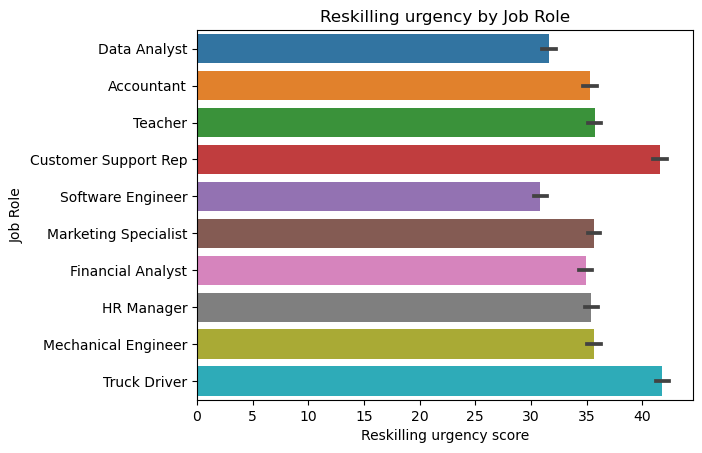

In [19]:
sns.barplot(x='reskilling_urgency_score', y='job_role', data=df)
plt.title('Reskilling urgency by Job Role')
plt.xlabel('Reskilling urgency score')
plt.ylabel('Job Role')
plt.show()

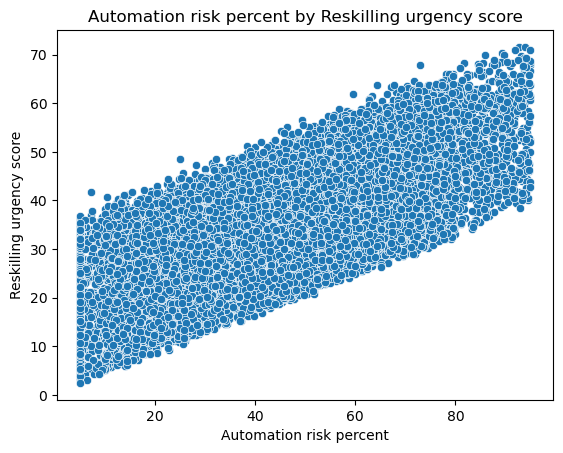

In [20]:
sns.scatterplot(x='automation_risk_percent', y='reskilling_urgency_score', data=df)
plt.title('Automation risk percent by Reskilling urgency score')
plt.xlabel('Automation risk percent')
plt.ylabel('Reskilling urgency score')
plt.show()

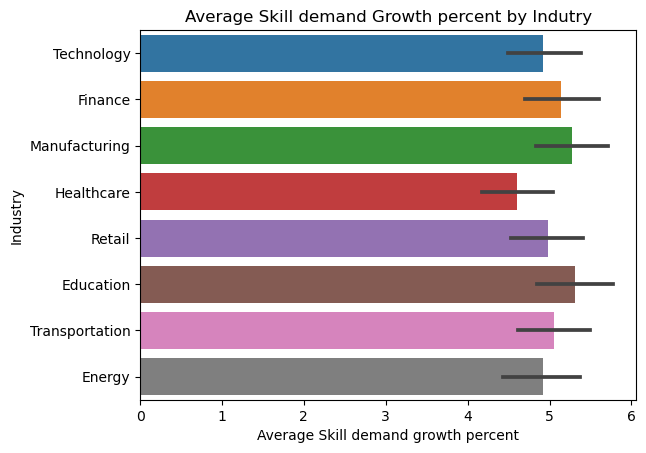

In [21]:
sns.barplot(x='skill_demand_growth_percent', y='industry', data=df)
plt.title('Average Skill demand Growth percent by Indutry')
plt.xlabel('Average Skill demand growth percent')
plt.ylabel('Industry')
plt.show()

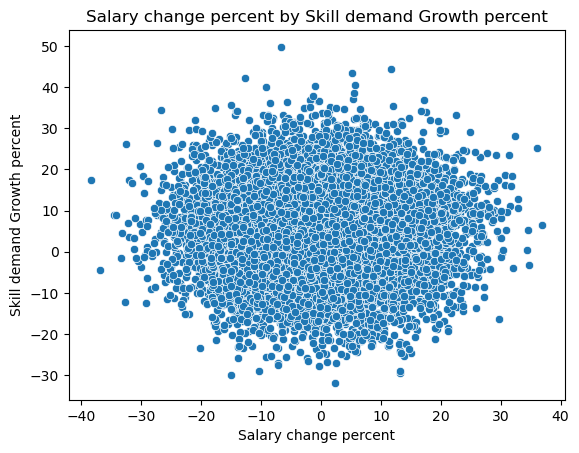

In [22]:
sns.scatterplot(x='salary_change_percent', y='skill_demand_growth_percent', data=df)
plt.title('Salary change percent by Skill demand Growth percent')
plt.xlabel('Salary change percent')
plt.ylabel('Skill demand Growth percent')
plt.show()

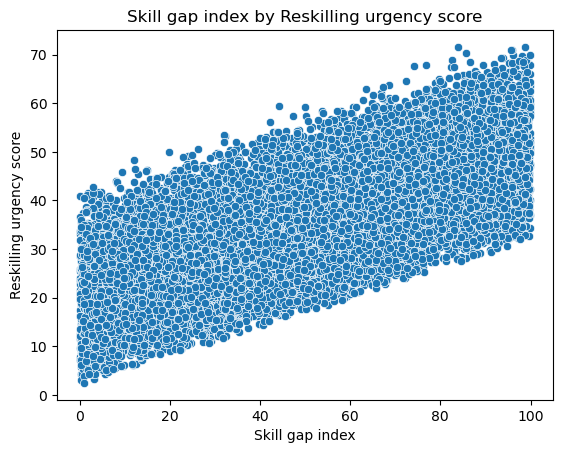

In [23]:
sns.scatterplot(x='skill_gap_index', y='reskilling_urgency_score', data=df)
plt.title('Skill gap index by Reskilling urgency score')
plt.xlabel('Skill gap index')
plt.ylabel('Reskilling urgency score')
plt.show()

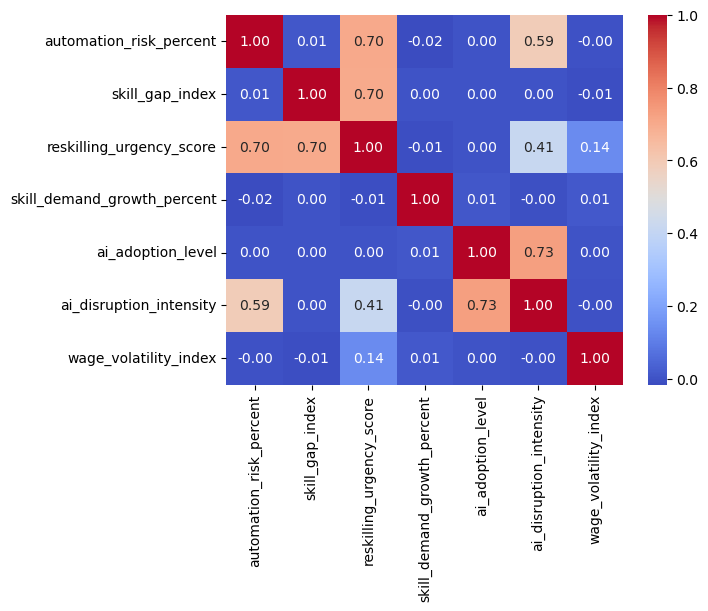

In [24]:
num_cols = ['automation_risk_percent', 'skill_gap_index', 
            'reskilling_urgency_score','skill_demand_growth_percent', 
            'ai_adoption_level', 'ai_disruption_intensity', 
            'wage_volatility_index']

sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [25]:
df[['ai_disruption_intensity', 'skill_transition_pressure']].corr()

,ai_disruption_intensity,skill_transition_pressure
ai_disruption_intensity,1.000000,0.355704
skill_transition_pressure,0.355704,1.000000


In [26]:
df[['automation_risk_percent', 'salary_change_percent']].corr()

,automation_risk_percent,salary_change_percent
automation_risk_percent,1.000000,-0.005281
salary_change_percent,-0.005281,1.000000


In [27]:
df[['remote_feasibility_score', 'automation_risk_percent']].corr()

,remote_feasibility_score,automation_risk_percent
remote_feasibility_score,1.000000,0.001511
automation_risk_percent,0.001511,1.000000


In [31]:
df['automation_risk_percent'].describe()

count    15000.000000
mean        46.176347
std         21.663635
min          5.000000
25%         28.790000
50%         46.235000
75%         63.602500
max         94.980000
Name: automation_risk_percent, dtype: float64

In [34]:
df['skill_gap_index'].describe()

count    15000.000000
mean        50.003708
std         28.811040
min          0.000000
25%         25.170000
50%         49.930000
75%         75.025000
max         99.980000
Name: skill_gap_index, dtype: float64

In [35]:
df['reskilling_urgency_score'].describe()

count    15000.000000
mean        35.867584
std         12.416415
min          2.456000
25%         26.982250
50%         35.871000
75%         44.698500
max         71.579000
Name: reskilling_urgency_score, dtype: float64

In [36]:
df['skill_demand_growth_percent'].describe()

count    15000.000000
mean         5.020461
std          9.956155
min        -31.880000
25%         -1.662500
50%          4.960000
75%         11.730000
max         49.790000
Name: skill_demand_growth_percent, dtype: float64

<Axes: xlabel='skill_gap_index', ylabel='Count'>

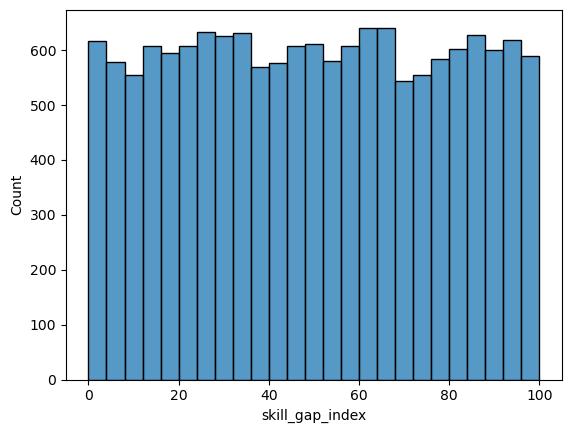

In [40]:
sns.histplot(x='skill_gap_index', data=df)

<Axes: xlabel='reskilling_urgency_score', ylabel='Count'>

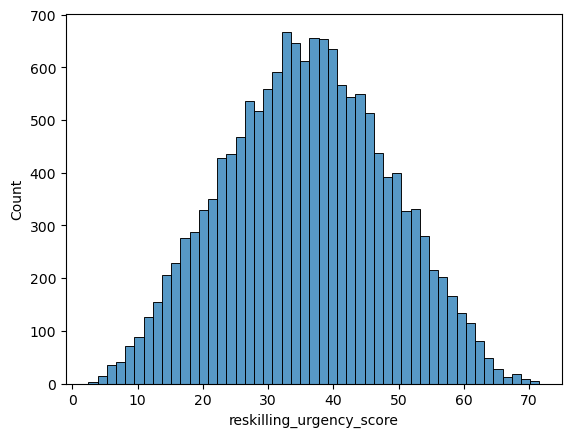

In [42]:
sns.histplot(x='reskilling_urgency_score', data=df)

<Axes: xlabel='wage_volatility_index'>

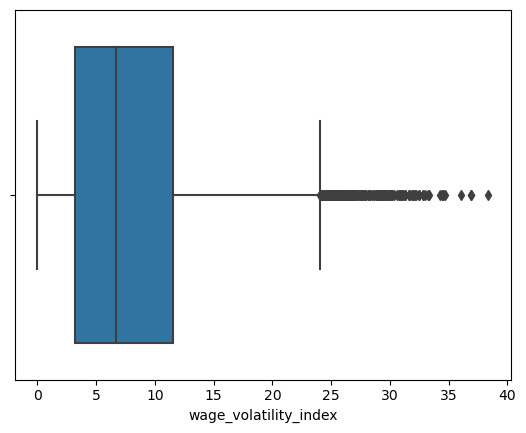

In [46]:
sns.boxplot(x='wage_volatility_index', data=df)

In [47]:
# Some roles have higher wage volatility index, indicating that those outliers
# may need urgent reskilling

<Axes: xlabel='year', ylabel='automation_risk_percent'>

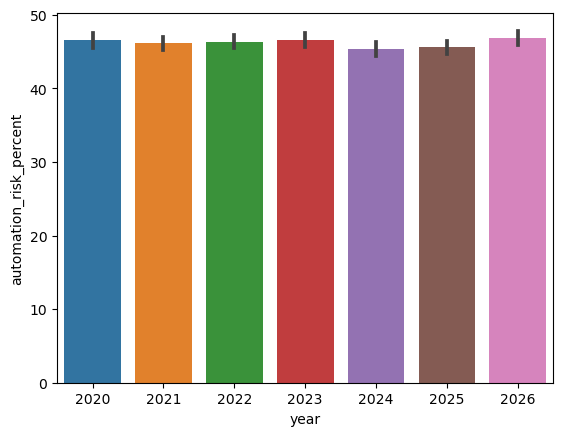

In [57]:
sns.barplot(x='year', y='automation_risk_percent', data=df)